# Credit Risk & Loan Default Prediction
## Phase 6 — Business Interpretation

**Goal of this notebook.** Turn the model's numbers into things a bank manager could act on, and be honest about what the analysis can and cannot claim. Three parts:

1. **Findings**: what the data says, in plain language, with concrete multiples ("X times as likely").
2. **Actions**: how a bank could use the model (risk tiers, pricing, extra-verification triggers, monitoring rules).
3. **Limitations**: data age and coverage, fairness, and what "prediction" does not mean.

**Which data is used where.** Descriptive findings use the **training set** (the larger sample, 120,000 borrowers). Anything that evaluates the model (risk tiers, fairness by age group) uses the **test set**, with all cut-offs decided from training data, as in Phase 5. Nothing here changes the model.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

from src.preprocessing import TARGET

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

train = pd.read_csv("../data/train.csv", index_col=0)
test = pd.read_csv("../data/test.csv", index_col=0)
X_train, y_train = train.drop(columns=TARGET), train[TARGET]
X_test, y_test = test.drop(columns=TARGET), test[TARGET]
model = joblib.load("../models/gradient_boosting.joblib")
UTIL = "RevolvingUtilizationOfUnsecuredLines"
BASE = y_train.mean()
print(f"Overall default rate (training set): {BASE:.2%}")

Overall default rate (training set): 6.68%


## Part 1 — Findings in plain language

### 1a. Single factors, expressed as "times as likely"
For each factor we compare a higher-risk group with a lower-risk group. **Relative risk** = the higher-risk group's default rate divided by the lower-risk group's.

In [2]:
tr = X_train.assign(default=y_train)

def rate(mask):
    return tr.loc[mask, "default"].mean()

comparisons = [
    ("Credit utilization", "over 75% of limit used", tr[UTIL] > 0.75, "under 25% used", tr[UTIL] < 0.25),
    ("Credit utilization", "over their limit (above 100%)", tr[UTIL] > 1.0, "under 25% used", tr[UTIL] < 0.25),
    ("Payment history", "late at least once in 2 years", tr.ever_late == 1, "never late", tr.ever_late == 0),
    ("Payment history", "90+ days late at least once", tr["NumberOfTimes90DaysLate"] >= 1, "never 90+ days late", tr["NumberOfTimes90DaysLate"] == 0),
    ("Age", "under 30", tr.age < 30, "age 60 and over", tr.age >= 60),
    ("Income (reported only)", "lowest fifth", (tr.income_missing_flag == 0) & (tr.MonthlyIncome <= tr.loc[tr.income_missing_flag == 0, "MonthlyIncome"].quantile(.2)),
     "highest fifth", (tr.income_missing_flag == 0) & (tr.MonthlyIncome >= tr.loc[tr.income_missing_flag == 0, "MonthlyIncome"].quantile(.8))),
]
rows = []
for factor, hi_label, hi, lo_label, lo in comparisons:
    rows.append({"Factor": factor, "Higher-risk group": hi_label, "Default rate": rate(hi) * 100,
                 "Lower-risk group": lo_label, "Default rate ": rate(lo) * 100,
                 "Times as likely": rate(hi) / rate(lo)})
findings = pd.DataFrame(rows)
findings.round({"Default rate": 1, "Default rate ": 1, "Times as likely": 1})

,Factor,Higher-risk group,Default rate,Lower-risk group,Default rate,Times as likely
0,Credit utilization,over 75% of limit used,20.5,under 25% used,2.1,9.5
1,Credit utilization,over their limit (above 100%),37.1,under 25% used,2.1,17.3
2,Payment history,late at least once in 2 years,22.2,never late,2.7,8.1
3,Payment history,90+ days late at least once,41.7,never 90+ days late,4.6,9.0
4,Age,under 30,11.5,age 60 and over,3.2,3.7
5,Income (reported only),lowest fifth,9.1,highest fifth,4.5,2.0


**What this shows.** Every comparison is expressed as *how many times as likely to default*. Payment history and utilization produce the biggest gaps (8-17 times), age a moderate gap (3.7 times), and income the smallest (2 times). These match the Phase 2 and Phase 5 findings and can be stated in plain English, for example: *"Borrowers using more than 75% of their credit limit were about 9.5 times as likely to default as those using under 25%."*

### 1b. How the two strongest factors combine

Payment history and utilization are the two things the model relies on most. Do they add up, or do they reinforce each other? The table shows the default rate in each combination.

Default rate (%), by payment history (rows) and credit utilization (columns):
RevolvingUtilizationOfUnsecuredLines  Under 25%  25-75%  Over 75%
total_late_payments                                              
Never late                                  1.2     4.0       8.4
Late once                                   5.8    10.5      22.8
Late 2+ times                              19.9    27.1      45.3

Number of borrowers in each cell:
RevolvingUtilizationOfUnsecuredLines  Under 25%  25-75%  Over 75%
total_late_payments                                              
Never late                                62237   21027     12369
Late once                                  5778    4093      3983
Late 2+ times                              2146    2736      5630


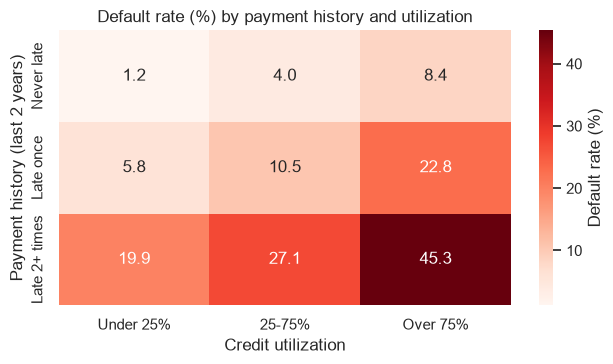

In [3]:
late_grp = pd.cut(tr.total_late_payments, [-1, 0, 1, 1000], labels=["Never late", "Late once", "Late 2+ times"])
util_grp = pd.cut(tr[UTIL], [-0.001, 0.25, 0.75, 5], labels=["Under 25%", "25-75%", "Over 75%"])

matrix = tr.groupby([late_grp, util_grp], observed=True)["default"].mean().unstack() * 100
counts = tr.groupby([late_grp, util_grp], observed=True)["default"].size().unstack()
print("Default rate (%), by payment history (rows) and credit utilization (columns):")
print(matrix.round(1).to_string())
print()
print("Number of borrowers in each cell:")
print(counts.to_string())

fig, ax = plt.subplots(figsize=(6.5, 3.8))
sns.heatmap(matrix, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Default rate (%)"}, ax=ax)
ax.set_xlabel("Credit utilization"); ax.set_ylabel("Payment history (last 2 years)")
ax.set_title("Default rate (%) by payment history and utilization")
plt.tight_layout()
plt.savefig("../reports/06_risk_matrix.png", dpi=150)
plt.show()

**What this shows.** The effects **compound** instead of merely adding. The safest corner (never late, under 25% utilization) defaults 1.2% of the time; the riskiest corner (late twice or more, over 75% utilization) defaults **45.3%**, about **38 times** as often. Moving along either direction alone raises risk a lot, and moving along both raises it much more. The heaviest cell by borrower count is the safest one (62,237 borrowers), while the riskiest cell holds only 5,630, which is why a small, well-targeted group accounts for many defaults.

### 1c. An early-warning group: borrowers with a clean record but heavy credit use
If a borrower has *never been late* but is already close to their limit, is that a warning sign?

In [4]:
clean = tr[tr.ever_late == 0]
u = pd.cut(clean[UTIL], [-0.001, 0.25, 0.5, 0.75, 1.0, 5], labels=["Under 25%", "25-50%", "50-75%", "75-100%", "Over limit"])
early = clean.groupby(u, observed=True)["default"].agg(default_rate="mean", borrowers="size")
early["default_rate"] *= 100
early["share_of_all_borrowers_%"] = early.borrowers / len(tr) * 100
early.round(1)

,default_rate,borrowers,share_of_all_borrowers_%
RevolvingUtilizationOfUnsecuredLines,,,
Under 25%,1.2,62237,51.9
25-50%,3.0,13247,11.0
50-75%,5.7,7780,6.5
75-100%,8.0,11417,9.5
Over limit,13.2,952,0.8


**What this shows.** Even among borrowers who have *never* been late, default risk rises with utilization: 1.2% under 25%, 8.0% at 75-100%, and 13.2% over the limit. About 12,400 borrowers (roughly one in ten) have a clean record but use over 75% of their credit; their default rate is about 8%, higher than the 6.7% portfolio average. That group is a natural candidate for an early-warning review, before any late payment shows up.

## Part 2 — How a bank could use the model

### 2a. Risk tiers
Instead of one yes/no line, banks usually sort applicants into a few tiers and treat each differently. We define four tiers by score cut-offs learned from **training data only** (cross-validated predictions), then check them on the **test set**:

| Tier | Who | Score percentile (training) |
|---|---|---|
| A: Low risk | safest half | bottom 50% |
| B: Moderate | next 30% | 50th-80th |
| C: Elevated | next 10% | 80th-90th |
| D: High | riskiest 10% | top 10% |

In [5]:
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
oof = cross_val_predict(clone(model), X_train, y_train, cv=cv, method="predict_proba", n_jobs=5)[:, 1]
cuts = np.quantile(oof, [0.50, 0.80, 0.90])
print("Score cut-offs learned from training data:", cuts.round(3))

score_test = model.predict_proba(X_test)[:, 1]
tier = pd.cut(score_test, [-np.inf, *cuts, np.inf], labels=["A: Low", "B: Moderate", "C: Elevated", "D: High"])
t = pd.DataFrame({"tier": tier, "default": y_test.values})
tiers = t.groupby("tier", observed=True).agg(borrowers=("default", "size"), defaulters=("default", "sum"), default_rate=("default", "mean"))
tiers["% of borrowers"] = tiers.borrowers / tiers.borrowers.sum() * 100
tiers["% of all defaulters"] = tiers.defaulters / tiers.defaulters.sum() * 100
tiers["times the average"] = tiers.default_rate / y_test.mean()
tiers["default_rate"] *= 100
tiers.round(1)

Score cut-offs learned from training data: [0.224 0.559 0.741]


,borrowers,defaulters,default_rate,% of borrowers,% of all defaulters,times the average
tier,,,,,,
A: Low,14997,135,0.9,50.0,6.7,0.1
B: Moderate,8928,392,4.4,29.8,19.6,0.7
C: Elevated,3096,364,11.8,10.3,18.2,1.8
D: High,2979,1114,37.4,9.9,55.6,5.6


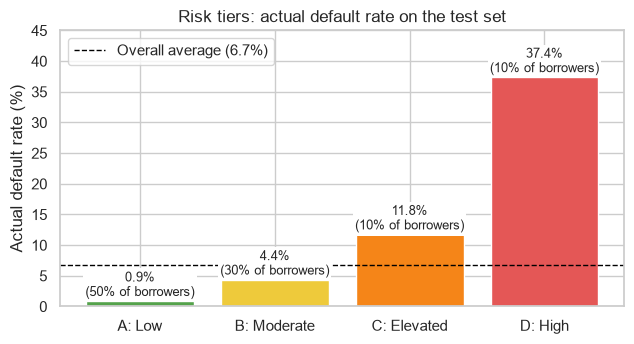

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
colors = ["#54A24B", "#EECA3B", "#F58518", "#E45756"]
ax.bar(tiers.index.astype(str), tiers.default_rate, color=colors)
ax.axhline(y_test.mean() * 100, color="black", ls="--", lw=1, label=f"Overall average ({y_test.mean():.1%})")
for i, (r, s) in enumerate(zip(tiers.default_rate, tiers["% of borrowers"])):
    ax.text(i, r + 0.8, f"{r:.1f}%\n({s:.0f}% of borrowers)", ha="center", fontsize=9,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
ax.set_ylabel("Actual default rate (%)"); ax.set_title("Risk tiers: actual default rate on the test set")
ax.set_ylim(0, 45); ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../reports/06_risk_tiers.png", dpi=150)
plt.show()

**What this shows.** The tiers separate risk sharply and in order. Tier D (the riskiest 10% of borrowers) defaulted **37.4%** of the time, 5.6 times the test-set average, and holds **55.6%** of all defaulters. Tier A (the safest half) defaulted only **0.9%** and holds 6.7% of defaulters, so a Tier D borrower was about 40 times as likely to default as a Tier A borrower. The tiers were defined from training data only and hold up on unseen borrowers.

### 2b. Illustrative uses of the tiers and the early-warning findings

These are **proposals for a bank to test**, not tested results. The data shows that risk differs sharply between groups; it does not show what would happen if a bank changed its behavior.

| Use | Idea | Evidence from this project |
|---|---|---|
| **Risk-based pricing** | Price and limit by tier rather than one rate for all | Tier D defaults many times as often as Tier A (table above), so one price cannot fit both |
| **Extra verification triggers** | Extra checks for Tier D, or when income is missing, or when the debt ratio looks unreliable | 20% of borrowers had no income and about 21% had an unusable debt ratio (Phase 1); those are the applications where the numbers can't be trusted |
| **Portfolio monitoring** | Existing customers who cross a warning line get a review or a call | The early-warning table above: borrowers with a clean record but utilization above 75% |
| **Collections prioritization** | Contact the highest-risk accounts first | Top decile holds the majority of all defaulters (Phase 5) |

**A caution on "reducing" risk.** The data shows heavy utilization *goes with* default. It does not show that lowering someone's utilization would make them safer; utilization may simply be a *symptom* of financial stress.

## Part 3 — Limitations and fairness

### 3a. Fairness: how does the model treat different age groups?
Age is one of the model's top drivers (Phase 5). In many places, using age directly in consumer-lending decisions is restricted or heavily scrutinized. Two questions:

1. **Does the model treat age groups differently?** At the Phase 5 cut-off, what share of each age group is flagged, and among borrowers who would have repaid, what share is wrongly flagged (the *false positive rate*)?
2. **What would dropping age cost?** Retrain the same model without `age` and compare test AUC.

In [7]:
# Re-derive the Phase 5 cut-off (cost ratio R = 5) from training-data predictions only
grid = np.linspace(0.02, 0.98, 97)
def avg_cost(t, ratio=5):
    flag = oof >= t
    fn = ((~flag) & (y_train.values == 1)).sum(); fp = (flag & (y_train.values == 0)).sum()
    return ratio * fn + fp
THRESHOLD = grid[np.argmin([avg_cost(t) for t in grid])]
print(f"Cut-off (R=5): {THRESHOLD:.2f}")

flag = score_test >= THRESHOLD
age_band = pd.cut(X_test.age, [17, 29, 39, 49, 59, 69, 120], labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"])
d = pd.DataFrame({"band": age_band.values, "flag": flag, "default": y_test.values})
rows = []
for b, g in d.groupby("band", observed=True):
    rows.append({"Age band": b, "Borrowers": len(g), "Actual default rate %": g["default"].mean() * 100,
                 "% flagged": g.flag.mean() * 100,
                 "Recall %": g.loc[g["default"] == 1, "flag"].mean() * 100,
                 "Good borrowers wrongly flagged %": g.loc[g["default"] == 0, "flag"].mean() * 100})
fair = pd.DataFrame(rows).set_index("Age band")
fair.round(1)

Cut-off (R=5): 0.71


,Borrowers,Actual default rate %,% flagged,Recall %,Good borrowers wrongly flagged %
Age band,,,,,
18-29,1803,12.6,20.0,64.3,13.6
30-39,4658,10.3,18.2,64.4,12.9
40-49,6930,8.5,14.7,60.6,10.4
50-59,6958,6.1,10.2,54.6,7.3
60-69,5813,3.4,5.7,52.3,4.1
70+,3838,2.2,2.8,37.2,2.0


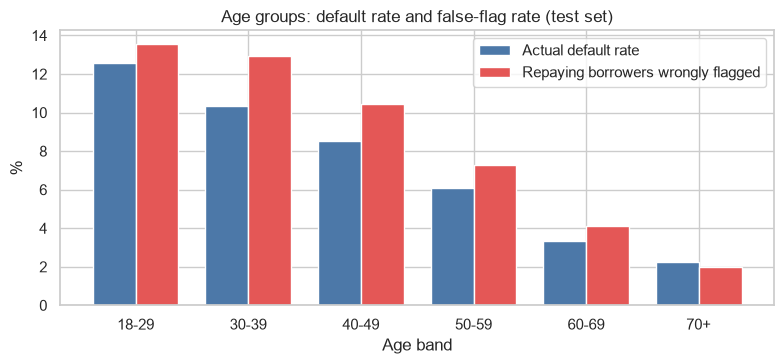

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(fair)); w = 0.38
ax.bar(x - w/2, fair["Actual default rate %"], w, label="Actual default rate", color="#4C78A8")
ax.bar(x + w/2, fair["Good borrowers wrongly flagged %"], w, label="Repaying borrowers wrongly flagged", color="#E45756")
ax.set_xticks(x); ax.set_xticklabels(fair.index)
ax.set_ylabel("%"); ax.set_xlabel("Age band"); ax.legend()
ax.set_title("Age groups: default rate and false-flag rate (test set)")
plt.tight_layout()
plt.savefig("../reports/06_age_fairness.png", dpi=150)
plt.show()

In [9]:
no_age = clone(model).fit(X_train.drop(columns="age"), y_train)
auc_with = roc_auc_score(y_test, score_test)
auc_without = roc_auc_score(y_test, no_age.predict_proba(X_test.drop(columns="age"))[:, 1])
print(f"Test AUC with age:    {auc_with:.4f}")
print(f"Test AUC without age: {auc_without:.4f}   (difference {auc_with - auc_without:+.4f})")

Test AUC with age:    0.8693
Test AUC without age: 0.8655   (difference +0.0038)


**What this shows.** The model treats age groups quite differently. Younger borrowers are flagged far more often (20.0% of 18-29-year-olds vs. 2.8% of those 70+), and among borrowers who *would have repaid*, 13.6% of the youngest are wrongly flagged vs. 2.0% of the oldest, a gap of about 6.8 times. Younger borrowers really do default more (12.6% vs. 2.2%, about 5.7 times), so some difference is expected, but the false-flag gap is somewhat larger than the default-rate gap. Removing age would cost very little accuracy (AUC 0.8655 without vs. 0.8693 with, a drop of 0.004). Does removing it fix the gap? The next table checks.

In [10]:
# Does removing age remove the age gap? Compare flag rates by age band at the SAME overall flag rate (same number of borrowers flagged)
score_no_age = no_age.predict_proba(X_test.drop(columns="age"))[:, 1]
k = int(flag.sum())
flag_no_age = np.zeros(len(y_test), bool); flag_no_age[np.argsort(-score_no_age)[:k]] = True
d["flag_no_age"] = flag_no_age
cmp = d.groupby("band", observed=True).agg(
    with_age=("flag", lambda s: s.mean() * 100),
    without_age=("flag_no_age", lambda s: s.mean() * 100),
).round(1)
cmp.columns = ["% flagged, model WITH age", "% flagged, model WITHOUT age"]
print(f"Both models flag the same {k:,} borrowers ({k/len(y_test):.1%}) overall.")
cmp

Both models flag the same 3,377 borrowers (11.3%) overall.


,"% flagged, model WITH age","% flagged, model WITHOUT age"
band,,
18-29,20.0,19.1
30-39,18.2,17.0
40-49,14.7,14.4
50-59,10.2,10.6
60-69,5.7,6.4
70+,2.8,3.5


**What this shows.** Not really. When the model is retrained without age and made to flag the same total number of borrowers, the flag rates barely move (18-29: 20.0% falls only to 19.1%; 70+: 2.8% rises only to 3.5%). Other variables (credit history, income, credit lines) still carry the age signal, so simply deleting the column does not remove the age gap. This is the standard "proxy" problem in fair lending, and the honest position is that it needs review by compliance and legal experts, not just a modeling tweak.

### 3b. Other limitations

- **Selection bias ("we only see the loans that were made").** Everyone in this dataset was a borrower who was actually given credit. Applicants who were rejected never appear, so we cannot know how they would have behaved. A model trained only on approved borrowers can be less reliable on the kinds of applicants the old policy rejected. Banks use "reject inference" techniques to address this; we do not.
- **Data age and origin.** The data dictionary was created in September 2011, and the data was released for a 2011 competition. Lending conditions and borrower behavior have changed since (interest rates, the pandemic, new products). We also don't know which country or lender it came from, so it should not be taken to represent any particular bank's customers or market.
- **One snapshot, one split.** We validated by random splitting. A real bank would also test *out of time* (train on earlier years, test on later ones), which is a tougher and more realistic check that this dataset can't support because it has no dates.
- **What "default" means here.** The target is "90+ days past due within two years". It says nothing about how much money is lost, and the data has no loan amount, interest rate, term or purpose, so we cannot compute profit or losses in currency terms. The cost ratio used for the cut-off is an assumption.
- **Scores are not probabilities.** Balanced class weights shift scores upward. Before using scores for pricing, a bank would calibrate them.
- **Missing and unreliable inputs.** 20% of borrowers had no income and about 21% had a debt ratio we judged unreliable. We filled these in and flagged them, but those rows are known less well than the rest.
- **Prediction is not causation.** The model finds signals of financial stress. It does not show that changing a borrower's utilization or age-related features would change their outcome.
- **Fairness can only be checked for what is in the data.** The only sensitive attribute present is age. There is no information on gender, ethnicity or other characteristics, so we can't audit against those, and a model can still disadvantage groups through proxies. In real use this would need legal and compliance review.

## Phase 6 summary (plain English)

**Findings**
1. **Heavy credit use is a strong warning sign.** Borrowers using over 75% of their credit limit defaulted at 20.5%, about **9.5 times** the rate of those using under 25% (2.1%). Borrowers over their limit defaulted at 37.1%, about **17 times** as often.
2. **Payment history is stronger still.** Late at least once means 22.2% default against 2.7% for never late, about **8 times** as likely. Once 90+ days late, 41.7% against 4.6%, about **9 times**.
3. **The two factors compound.** A borrower who is never late and uses under 25% of credit defaults 1.2% of the time. One who has been late twice or more and uses over 75% defaults **45.3%** of the time, roughly **38 times** as often.
4. **Age and income matter, but less.** Under-30s default about 3.7 times as often as those 60 and over, and the lowest-income fifth about twice as often as the highest.
5. **A clean record is not a guarantee.** Borrowers who have never been late but use over 75% of their credit still default more than 8% of the time, well above the 1.2% for clean-record, low-use borrowers.

**How a bank could use the model.** Sort borrowers into four tiers. On the test set, the **riskiest 10% (Tier D) defaulted 37.4% of the time (5.6 times the average) and hold 56% of all defaulters**, while the **safest half (Tier A) defaulted 0.9%** and hold only 7% of defaulters. That supports pricing by tier, extra verification for Tier D or for applications with missing income, monitoring existing customers who cross a utilization or lateness warning line, and prioritizing collections. These are proposals to test, not measured results.

**Fairness.** The model flags younger borrowers far more often: 20.0% of 18-29-year-olds versus 2.8% of those 70+, and 13.6% of *repaying* young borrowers are wrongly flagged versus 2.0% of repaying borrowers 70+. Part of that reflects real differences in default rates (12.6% vs 2.2%), but the gap in false flags (about 6.8 times) is somewhat larger than the gap in default rates (about 5.7 times). **Removing age would not fix this**: without age, flag rates barely change (19.1% vs 3.5%), because other variables (credit history, income, credit lines) carry age information. Dropping age costs only 0.004 AUC (0.8655 vs 0.8693). The honest statement is that this is a real tension in credit scoring, and that real lenders manage it with legal review, not just by deleting a column.